# [SOLUTION] XAI (Explainable AI) with Wine Dataset

## Overview

In this notebook we apply **Explainable AI (XAI)** techniques to a classic problem:  
**Can a machine tell Red Wine from White Wine using only three numbers on the label?**

| Feature | Description |
|---------|-------------|
| `alcohol` | Alcohol content (%) |
| `sugar` | Residual sugar (g/L) |
| `pH` | Acidity level |
| `class` | **Target**: 0 = Red Wine, 1 = White Wine |

### Why XAI?
A machine learning model is like a "black box": it gives answers but doesn't explain *why*.  
XAI tools help us **open the box** and understand:
- Which features matter most?
- How does each feature influence the prediction?
- Where does the model make mistakes?

### Techniques Covered
1. **Feature Importance** — Which feature does the model rely on most?
2. **Partial Dependence Plots (PDP)** — How does one feature change the prediction?
3. **2D PDP** — How do two features interact?
4. **Confusion Matrix** — Where does the model go wrong?
5. **Hyperparameter Tuning (GridSearchCV)** — How can we make the model better?

> **Note:** This is the **solution notebook**. A separate `lab` notebook has blanks for you to fill in!

## Section 0 — Install Dependencies

Run this cell once to make sure all required packages are installed.

- `xgboost`: The XGBoost gradient-boosting library (faster than sklearn's GradientBoosting)
- `scikit-learn`: For data splitting, cross-validation, PDP, confusion matrix
- `matplotlib`: For drawing plots
- `pandas`: For loading and handling tabular data
- `numpy`: For numerical operations

In [40]:
# Install all required packages
# Run this cell if you get an ImportError below
%pip install xgboost scikit-learn matplotlib pandas numpy graphviz --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Section 1 — Load the Wine Dataset

We load `wine.csv` from `data/wine.csv`.

For Colab, uploaded files are commonly under `/content`, so move them to `/content/data` first.

### Colab quick shell (optional)
```bash
mkdir -p /content/data
mv /content/wine.csv /content/data/wine.csv
```

Path resolution order in this notebook:
1. `/content/data/wine.csv`
2. `./data/wine.csv`
3. `../data/wine.csv`

The dataset has **6,497 wine samples** collected from a Portuguese winery.

- **0 (Red Wine)**: ~1,599 samples — dry, tannic, higher acidity
- **1 (White Wine)**: ~4,898 samples — fruity, lighter, more residual sugar

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -- Resolve wine.csv path for both Colab and local environments
candidates = [
    Path('/content/data/wine.csv'),
    Path('./data/wine.csv'),
    Path('../data/wine.csv'),
    Path('/content/wine.csv'),
]

for candidate in candidates:
    if candidate.exists():
        csv_path = candidate.resolve()
        break
else:
    raise FileNotFoundError(
        "wine.csv not found. Expected one of: /content/data/wine.csv, ./data/wine.csv, ../data/wine.csv"
    )

print(f"✓ Loading data from: {csv_path}")

# -- Load the CSV into a DataFrame
wine = pd.read_csv(csv_path)

print(f"\nDataset shape: {wine.shape[0]} rows × {wine.shape[1]} columns")
wine.head()

✓ Loading data from: /Users/songhune/Library/CloudStorage/SynologyDrive-Document/2026-1/특강-한중연/wine.csv

Dataset shape: 6497 rows × 4 columns


,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [42]:
# ── Explore the dataset ────────────────────────────────────────
# .info() shows column names, data types, and if there are missing values
print("=== Dataset Info ===")
wine.info()

print("\n=== Basic Statistics ===")
# .describe() shows count, mean, min, max, and percentiles for each column
wine.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB

=== Basic Statistics ===


,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [43]:
# ── Check class balance ────────────────────────────────────────
# value_counts() shows how many samples belong to each class
class_counts = wine['class'].value_counts()
print("Class distribution:")
print(f"  Red Wine  (class=0): {class_counts[0]} samples")
print(f"  White Wine(class=1): {class_counts[1]} samples")
print(f"\nClass imbalance ratio: {class_counts[1]/class_counts[0]:.1f}x more white than red")
print("Note: The dataset is imbalanced — white wine has ~3x more samples than red wine.")

Class distribution:
  Red Wine  (class=0): 1599 samples
  White Wine(class=1): 4898 samples

Class imbalance ratio: 3.1x more white than red
Note: The dataset is imbalanced — white wine has ~3x more samples than red wine.


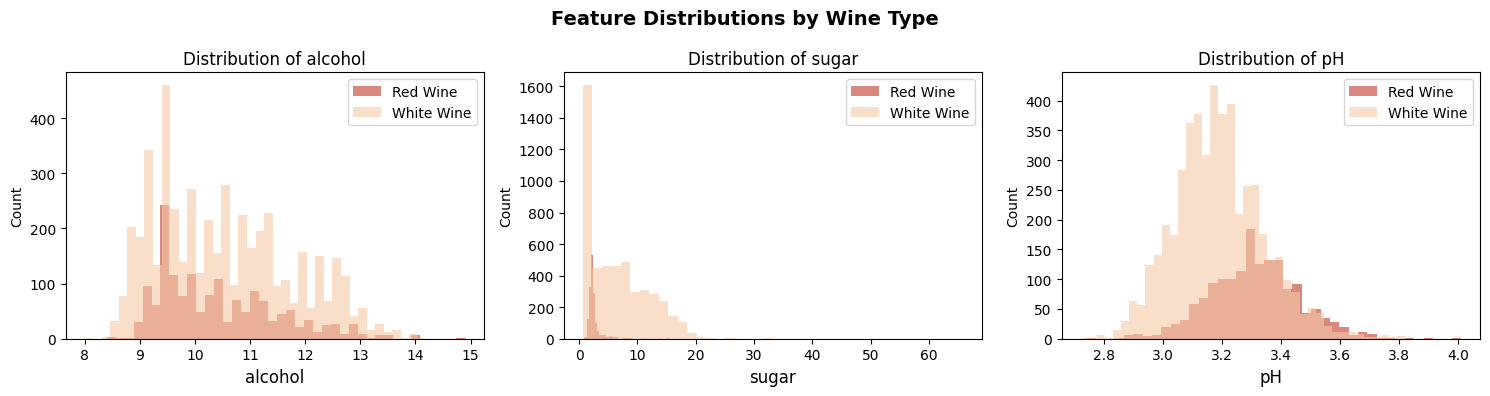


Key observations:
• Alcohol: Red wine tends to have slightly lower alcohol content than white wine
• Sugar: White wine has much higher residual sugar (some are sweet wines)
• pH: Red wine has slightly higher pH (less acidic) than white wine
→ Sugar appears to be the most discriminative feature at first glance!



In [44]:
# ── Visualize feature distributions by class ───────────────────
# This helps us understand which features naturally separate red from white wine

feature_names = ['alcohol', 'sugar', 'pH']
colors = {0: '#c0392b', 1: '#f5cba7'}  # Red for red wine, light orange for white
labels = {0: 'Red Wine', 1: 'White Wine'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions by Wine Type', fontsize=14, fontweight='bold')

for ax, feature in zip(axes, feature_names):
    for cls in [0, 1]:
        # Plot histogram for each class separately
        subset = wine[wine['class'] == cls][feature]
        ax.hist(subset, bins=40, alpha=0.6, color=colors[cls], label=labels[cls])
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {feature}')
    ax.legend()

plt.tight_layout()
plt.show()

print("""
Key observations:
• Alcohol: Red wine tends to have slightly lower alcohol content than white wine
• Sugar: White wine has much higher residual sugar (some are sweet wines)
• pH: Red wine has slightly higher pH (less acidic) than white wine
→ Sugar appears to be the most discriminative feature at first glance!
""")

## Section 2 — Train / Test Split

Before training a model, we split data into:
- **Training set (80%)**: Used to teach the model
- **Test set (20%)**: Held back to evaluate how well the model generalises

Think of it like studying with a textbook (training) and then taking an exam on unseen questions (testing).

In [45]:
from sklearn.model_selection import train_test_split

# ── Separate features (X) from the label (y) ──────────────────
# X: the three chemical measurements (input to the model)
# y: the class label (0=red, 1=white) — what we want to predict
FEATURE_COLS = ['alcohol', 'sugar', 'pH']
TARGET_COL   = 'class'

X = wine[FEATURE_COLS].to_numpy()           # shape: (6497, 3)
y = wine[TARGET_COL].astype(int).to_numpy() # shape: (6497,)

# ── Split into train and test sets ────────────────────────────
# test_size=0.2  → 20% for testing, 80% for training
# random_state=42 → fixes the random seed so results are reproducible
# stratify=y     → ensures each split has the same class ratio (important for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("\nTree-based models generally work well on raw numeric scales.")
print("So we continue with the original features here.")

Training set: 5197 samples
Test set:     1300 samples

Tree-based models generally work well on raw numeric scales.
So we continue with the original features here.


## Section 2.5 — Information Gain with Gini and Cross-Entropy (Hand Calculation + Code)

This mini section mirrors the decision-tree logic used in [0407] and [0410].
We compare two candidate root questions on a tiny dataset.

### Example Dataset
We want to classify `Exercise = Yes/No` from 6 samples:

| ID | Weather | Temperature | Exercise |
|---:|---------|-------------|----------|
| 1 | Sunny  | Hot  | No  |
| 2 | Sunny  | Mild | Yes |
| 3 | Cloudy | Mild | Yes |
| 4 | Rain   | Mild | Yes |
| 5 | Rain   | Cold | No  |
| 6 | Cloudy | Cold | Yes |

Candidate A: `Weather == Cloudy?`

Candidate B: `Temperature == Cold?`

### Step-by-step formulas
For a node with class probabilities $p_k$:

$$
\mathrm{Gini}=1-\sum_k p_k^2
$$

$$
\mathrm{Entropy}= -\sum_k p_k\log_2 p_k
$$

For split question $Q$:

$$
\mathrm{WeightedImpurity}(Q)=\sum_{j\in\{L,R\}}\frac{|S_j|}{|S|}\,\mathrm{Impurity}(S_j)
$$

$$
\mathrm{Gain}(Q)=\mathrm{Impurity}(S)-\mathrm{WeightedImpurity}(Q)
$$

When impurity is entropy, this is the standard information gain.
Using cross-entropy notation,

$$
H(p,q)=-\sum_k p_k\log_2 q_k
$$

and at each node, if we set $q=p$, then $H(p,q)=H(p)$.
So minimizing weighted node cross-entropy is equivalent to maximizing entropy-based information gain.

### Hand results (target values)
- Parent node: Yes=4, No=2
- Parent Gini: $1-(\frac{4}{6})^2-(\frac{2}{6})^2=\frac{4}{9}\approx0.444$
- Parent Entropy: $-\frac{4}{6}\log_2\frac{4}{6}-\frac{2}{6}\log_2\frac{2}{6}\approx0.918$

Split A (`Cloudy?`):
- Weighted Gini: $\frac{2}{6}\cdot0+\frac{4}{6}\cdot0.5=0.333$
- Gini Gain: $0.444-0.333=0.111$
- Weighted Entropy: $\frac{2}{6}\cdot0+\frac{4}{6}\cdot1=0.667$
- Information Gain: $0.918-0.667=0.251$

Split B (`Cold?`):
- Weighted Gini: $\frac{2}{6}\cdot0.5+\frac{4}{6}\cdot0.375=0.417$
- Gini Gain: $0.444-0.417=0.027$
- Weighted Entropy: $\frac{2}{6}\cdot1+\frac{4}{6}\cdot0.811\approx0.874$
- Information Gain: $0.918-0.874\approx0.044$

Root choice: Candidate A (`Weather == Cloudy?`) because it gives the larger gain under both criteria.

In [46]:
import math
import pandas as pd

# Tiny example dataset used above
mini = pd.DataFrame({
    'weather': ['Sunny', 'Sunny', 'Cloudy', 'Rain', 'Rain', 'Cloudy'],
    'temperature': ['Hot', 'Mild', 'Mild', 'Mild', 'Cold', 'Cold'],
    'exercise': ['No', 'Yes', 'Yes', 'Yes', 'No', 'Yes'],
})

def gini_from_counts(counts):
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]
    return 1 - sum(p**2 for p in probs)

def entropy_from_counts(counts):
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]
    return -sum(p * math.log2(p) for p in probs)

def split_scores(df, mask_col, positive_value):
    left = df[df[mask_col] == positive_value]['exercise']
    right = df[df[mask_col] != positive_value]['exercise']

    parent_counts = df['exercise'].value_counts().reindex(['No', 'Yes'], fill_value=0).tolist()
    left_counts = left.value_counts().reindex(['No', 'Yes'], fill_value=0).tolist()
    right_counts = right.value_counts().reindex(['No', 'Yes'], fill_value=0).tolist()

    parent_gini = gini_from_counts(parent_counts)
    parent_entropy = entropy_from_counts(parent_counts)

    left_w = len(left) / len(df)
    right_w = len(right) / len(df)

    split_gini = left_w * gini_from_counts(left_counts) + right_w * gini_from_counts(right_counts)
    split_entropy = left_w * entropy_from_counts(left_counts) + right_w * entropy_from_counts(right_counts)

    return {
        'parent_gini': parent_gini,
        'parent_entropy': parent_entropy,
        'split_gini': split_gini,
        'gini_gain': parent_gini - split_gini,
        'split_entropy': split_entropy,
        'info_gain': parent_entropy - split_entropy,
    }

score_a = split_scores(mini, 'weather', 'Cloudy')
score_b = split_scores(mini, 'temperature', 'Cold')

print('Parent Gini        :', round(score_a['parent_gini'], 3))
print('Parent Entropy     :', round(score_a['parent_entropy'], 3))
print('\nCandidate A (Weather == Cloudy)')
print('  Weighted Gini    :', round(score_a['split_gini'], 3))
print('  Gini Gain        :', round(score_a['gini_gain'], 3))
print('  Weighted Entropy :', round(score_a['split_entropy'], 3))
print('  Information Gain :', round(score_a['info_gain'], 3))

print('\nCandidate B (Temperature == Cold)')
print('  Weighted Gini    :', round(score_b['split_gini'], 3))
print('  Gini Gain        :', round(score_b['gini_gain'], 3))
print('  Weighted Entropy :', round(score_b['split_entropy'], 3))
print('  Information Gain :', round(score_b['info_gain'], 3))

best = 'A (Weather == Cloudy)' if score_a['info_gain'] > score_b['info_gain'] else 'B (Temperature == Cold)'
print(f'\nBest root question by gain: {best}')

Parent Gini        : 0.444
Parent Entropy     : 0.918

Candidate A (Weather == Cloudy)
  Weighted Gini    : 0.333
  Gini Gain        : 0.111
  Weighted Entropy : 0.667
  Information Gain : 0.252

Candidate B (Temperature == Cold)
  Weighted Gini    : 0.417
  Gini Gain        : 0.028
  Weighted Entropy : 0.874
  Information Gain : 0.044

Best root question by gain: A (Weather == Cloudy)


## Section 3 — Baseline Tree Models: Decision Tree, Random Forest, Extra Trees
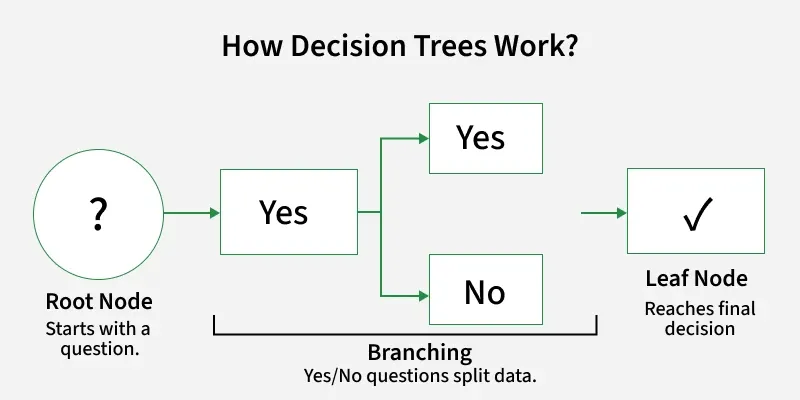
- Decision Tree: single interpretable tree
- Random Forest: bagging ensemble of many trees
- Extra Trees: stronger randomization at split points

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_validate

baseline_models = {
    'DecisionTree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42),
}

print('=== 5-fold CV on training split ===')
for name, m in baseline_models.items():
    cv = cross_validate(m, X_train, y_train, return_train_score=True, n_jobs=-1)
    print(f"{name:12s} | train={cv['train_score'].mean():.4f} | valid={cv['test_score'].mean():.4f}")

print('\n=== test accuracy ===')
for name, m in baseline_models.items():
    m.fit(X_train, y_train)
    print(f"{name:12s} | test={m.score(X_test, y_test):.4f}")

=== 5-fold CV on training split ===
DecisionTree | train=0.8488 | valid=0.8380
RandomForest | train=0.9982 | valid=0.8922
ExtraTrees   | train=0.9982 | valid=0.8907

=== test accuracy ===
DecisionTree | test=0.8408
RandomForest | test=0.8892
ExtraTrees   | test=0.8815


## Section 4 — Train the XGBoost Model

**XGBoost** (eXtreme Gradient Boosting) builds many simple decision trees one by one, where each new tree fixes the errors of the previous ones.  
It is one of the most powerful and widely-used algorithms for tabular (structured) data.

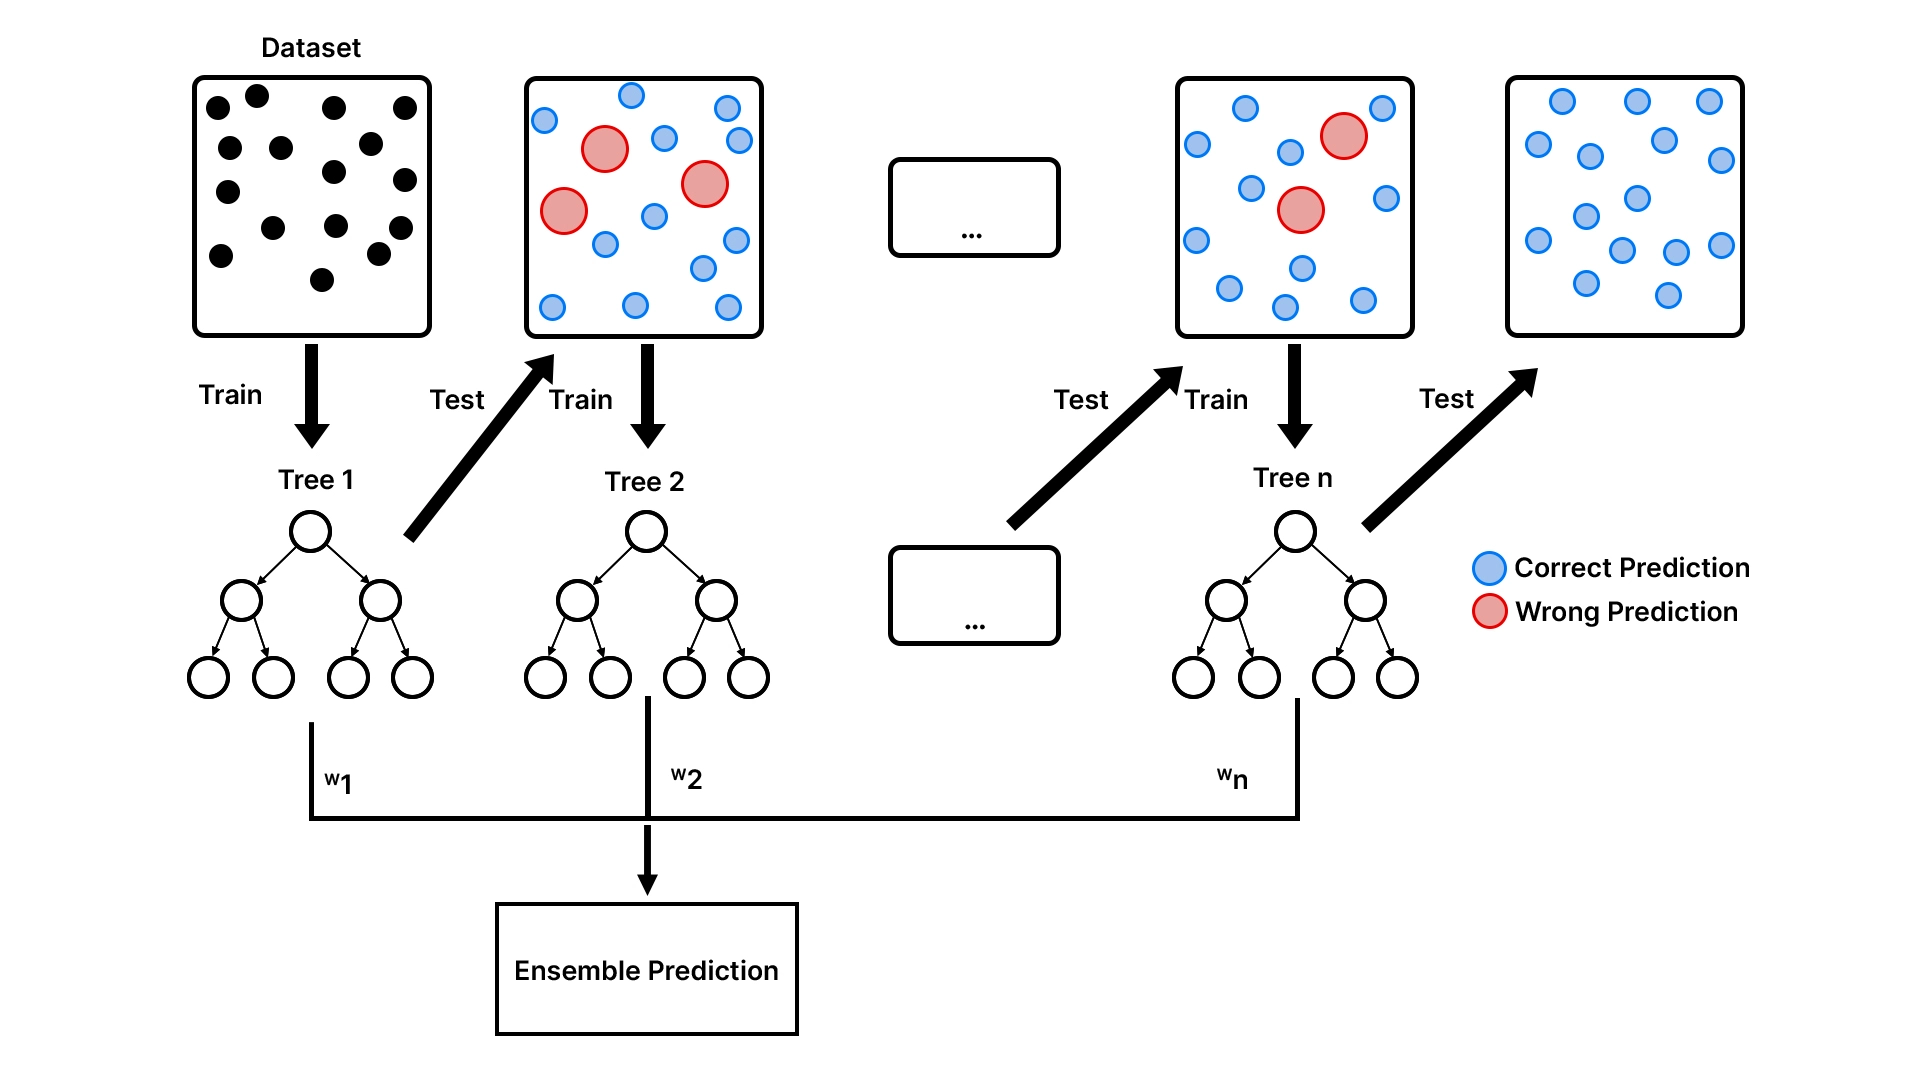
This process is called **boosting** — it "boosts" weak learners into a strong one.

In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ── Train a default XGBoost model ─────────────────────────────
# XGBClassifier default settings:
#   - n_estimators=100:  build 100 boosted trees
#   - max_depth=6:       each tree can be up to 6 levels deep
#   - learning_rate=0.3: how much each tree corrects the previous error
#   - eval_metric='logloss': use log-loss to measure classification error during training
model = XGBClassifier(
    eval_metric='logloss',  # suppress a harmless warning
    random_state=42
)

# model.fit() trains the model on the training data
model.fit(X_train, y_train)

# ── Evaluate accuracy ─────────────────────────────────────────
y_pred_train = model.predict(X_train)  # predictions on training set
y_pred_test  = model.predict(X_test)   # predictions on test set

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test     Accuracy: {test_acc:.2%}")
print()
if train_acc - test_acc > 0.05:
    print("⚠ Large gap between train & test accuracy → possible overfitting!")
else:
    print("✓ Train and test accuracy are close → good generalisation.")

Training Accuracy: 95.11%
Test     Accuracy: 87.77%

⚠ Large gap between train & test accuracy → possible overfitting!


## Section 5 — XAI Technique 1: Confusion Matrix

A **confusion matrix** shows which samples were correctly classified and which were not.  

For binary classification (red vs white):

```
               Predicted Red   Predicted White
Actual Red    [ True Negative   False Positive ]
Actual White  [ False Negative  True Positive  ]
```
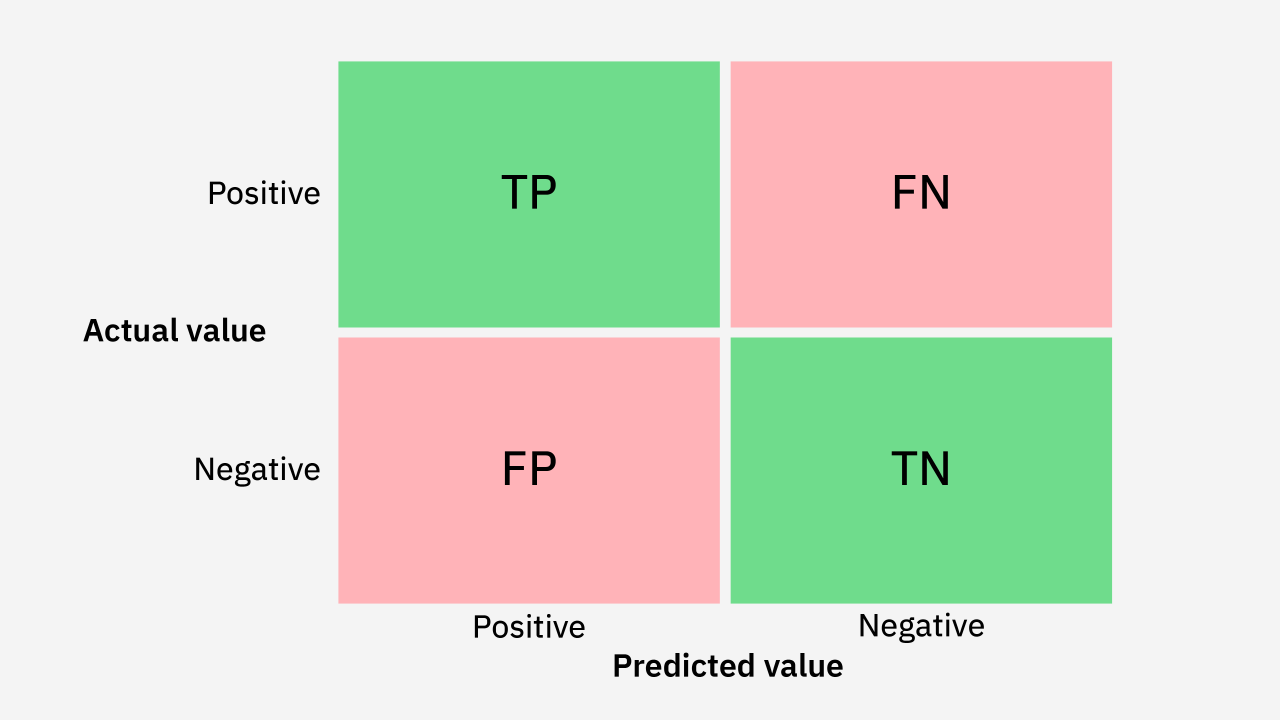
- **True Negative (TN)**: Correctly said "Red"
- **True Positive (TP)**: Correctly said "White"
- **False Positive (FP)**: Said "White", but it was Red → model mislabeled red as white
- **False Negative (FN)**: Said "Red", but it was White → model mislabeled white as red

Confusion Matrix:
[[231  89]
 [ 70 910]]


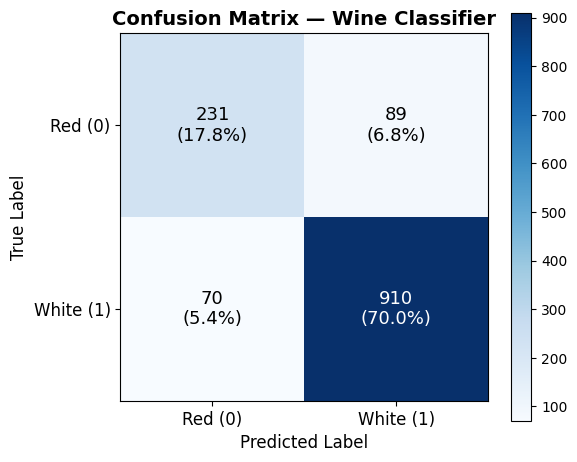


Classification Report:
              precision    recall  f1-score   support

    Red Wine       0.77      0.72      0.74       320
  White Wine       0.91      0.93      0.92       980

    accuracy                           0.88      1300
   macro avg       0.84      0.83      0.83      1300
weighted avg       0.88      0.88      0.88      1300

Precision = 0.911  → when we predict 'white', how often are we correct?
Recall    = 0.929  → of all actual white wines, how many did we catch?


In [49]:
import itertools
from sklearn.metrics import confusion_matrix, classification_report

# ── Compute confusion matrix ───────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm)

# ── Visualise as a colour-coded grid ──────────────────────────
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    """Plots a confusion matrix with colour coding."""
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, fontsize=12)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names, fontsize=12)

    # Write the count and percentage inside each cell
    total = cm.sum()
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm[i, j]}\n({cm[i, j]/total:.1%})",
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=13)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, ['Red (0)', 'White (1)'], title='Confusion Matrix — Wine Classifier')

# ── Detailed metrics ───────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Red Wine', 'White Wine']))

# ── Compute key metrics manually to understand them ───────────
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
print(f"Precision = {precision:.3f}  → when we predict 'white', how often are we correct?")
print(f"Recall    = {recall:.3f}  → of all actual white wines, how many did we catch?")

### Precision vs Recall: When Each Metric Helps

> Both metrics come from the confusion matrix, but they answer different practical questions.

| Metric | Core question it answers | Most useful when | Typical examples | If too low... |
|---|---|---|---|---|
| **Precision** $=\frac{TP}{TP+FP}$ | "When the model predicts White, how often is it correct?" | False positives are costly (you want fewer wrong alarms) | Spam filter, fraud alert review load, expensive follow-up tests | You waste resources on many false alarms |
| **Recall** $=\frac{TP}{TP+FN}$ | "Of all actual White wines, how many did we catch?" | False negatives are costly (you do not want to miss true cases) | Disease screening, safety defect detection, risk monitoring | You miss many true cases that should be detected |

### Practical interpretation tip
- Use **Precision** when "wrong positive decisions" hurt more.
- Use **Recall** when "missed true cases" hurt more.
- In practice, tune the classification threshold to trade off Precision and Recall based on business goals.

## Section 6 — XAI Technique 2: Feature Importance

Feature importance answers: **"Which feature does the model rely on most?"**

XGBoost computes importance by counting how much each feature improves the splits across all trees.  
A higher score = the model uses that feature more frequently and effectively.

This is useful for:
- Understanding what the model has learned
- Deciding which features to collect in the future
- Removing irrelevant features to simplify the model

| Criterion | Keyword phrase             | When to use it                                                                 |
|----------|----------------------------|--------------------------------------------------------------------------------|
| Gain     | performance contribution   | When you want an intuitive view of how much each feature improves performance |
| Cover    | sample impact              | When you want to find features that are key splits affecting many samples     |
| Weight   | split frequency (caution)  | When you want a quick, rough view of how often features are used for splits   |

  alcohol   : 0.1941  (19.4%)
  sugar     : 0.6292  (62.9%)
  pH        : 0.1767  (17.7%)


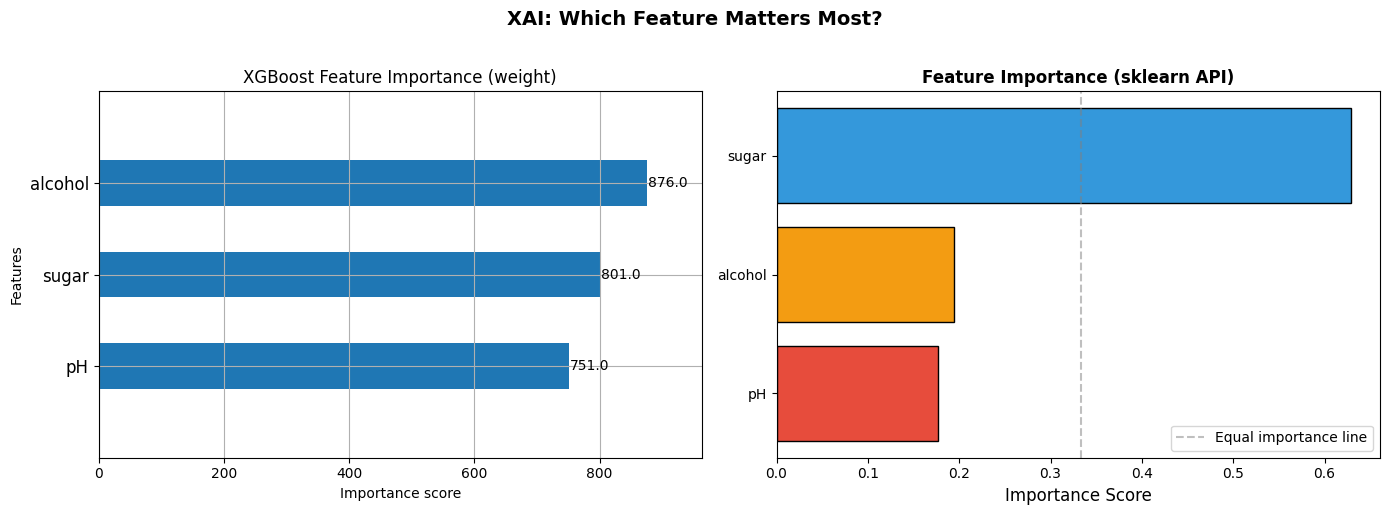


Interpretation:
• Sugar has the highest importance → residual sugar is the strongest indicator.
  (White wines can be sweet dessert wines; red wines are almost always dry.)
• Alcohol is the second most important feature.
• pH contributes the least but is still used by the model.



In [50]:
from xgboost import plot_importance

# ── Extract raw importance scores ──────────────────────────────
# feature_importances_ gives a normalised score (0 to 1) for each feature
importances = model.feature_importances_

for name, score in zip(FEATURE_COLS, importances):
    print(f"  {name:10s}: {score:.4f}  ({score*100:.1f}%)")

# ── Plot using XGBoost's built-in function ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Built-in XGBoost importance plot (uses 'weight' by default)
plot_importance(model, ax=axes[0], title='XGBoost Feature Importance (weight)',
                height=0.5, importance_type='weight')
axes[0].set_yticklabels(['pH', 'sugar', 'alcohol'], fontsize=12)

# Right: Custom bar chart using feature_importances_ (gain-based by default in sklearn API)
sorted_idx = np.argsort(importances)
axes[1].barh([FEATURE_COLS[i] for i in sorted_idx], importances[sorted_idx],
             color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='black')
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('Feature Importance (sklearn API)', fontsize=12, fontweight='bold')
axes[1].axvline(x=1/3, color='gray', linestyle='--', alpha=0.5, label='Equal importance line')
axes[1].legend()

plt.suptitle('XAI: Which Feature Matters Most?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
Interpretation:
• Sugar has the highest importance → residual sugar is the strongest indicator.
  (White wines can be sweet dessert wines; red wines are almost always dry.)
• Alcohol is the second most important feature.
• pH contributes the least but is still used by the model.
""")

## Section 7 — XAI Technique 3: 1D Partial Dependence Plot (PDP)

A **Partial Dependence Plot** answers:  
**"If I change the alcohol content while keeping sugar and pH constant, how does the model's prediction change?"**

The Y-axis shows the **predicted probability of being White Wine** (class=1).  
- Near 0 → model predicts Red Wine  
- Near 1 → model predicts White Wine  

This reveals the **direction** and **shape** of each feature's effect on the model's decision.

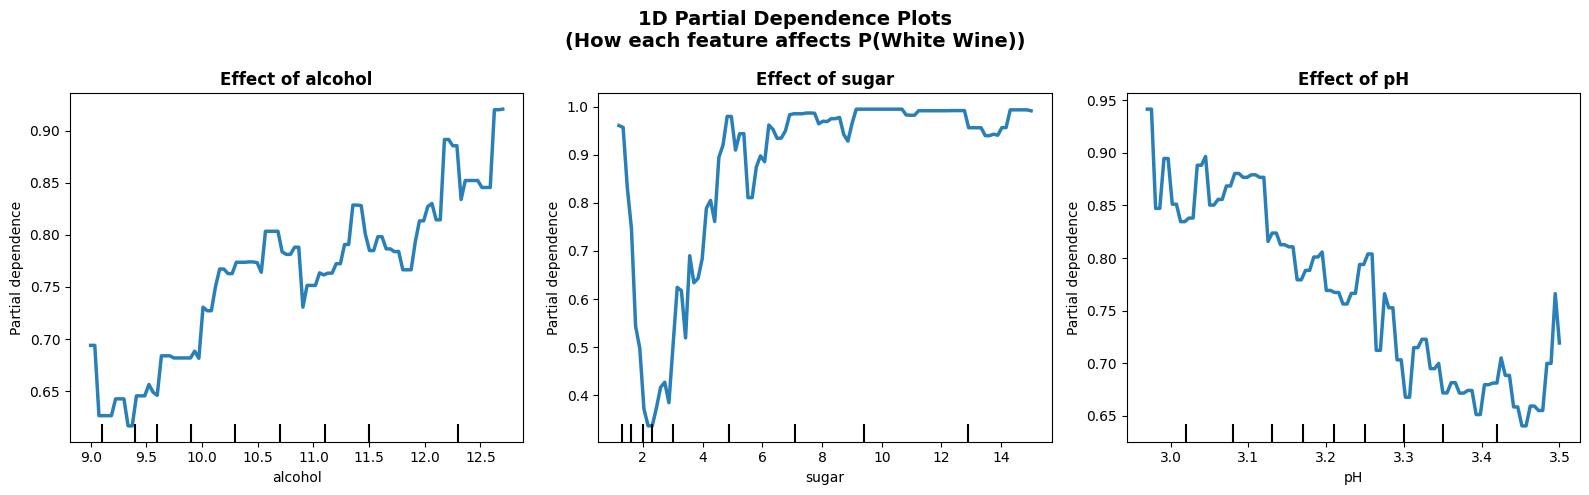


How to read these plots:
───────────────────────────────────────────────────────────────
  alcohol: As alcohol % increases, P(White Wine) increases.
           → Higher alcohol content leans toward white wine.

  sugar:   As sugar increases, P(White Wine) rises sharply.
           → Sweeter wine is almost certainly white wine.
           (Red wines rarely have high residual sugar.)

  pH:      Lower pH (more acidic) → higher P(White Wine).
           → White wines tend to be more acidic than red.
───────────────────────────────────────────────────────────────
The red dashed line at 0.5 is the decision threshold:
above it = predicted White, below it = predicted Red.



In [51]:
from sklearn.inspection import PartialDependenceDisplay

# ── 1D Partial Dependence Plots for all three features ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('1D Partial Dependence Plots\n(How each feature affects P(White Wine))',
             fontsize=14, fontweight='bold')

for ax, feature in zip(axes, FEATURE_COLS):
    PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_train,                  # Use training data to define the feature ranges
        features=[FEATURE_COLS.index(feature)],  # Which feature to plot
        feature_names=FEATURE_COLS,
        ax=ax,
        line_kw={'color': '#2980b9', 'linewidth': 2.5}
    )
    ax.set_title(f'Effect of {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel('P(White Wine)', fontsize=11)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='Decision boundary (0.5)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("""
How to read these plots:
───────────────────────────────────────────────────────────────
  alcohol: As alcohol % increases, P(White Wine) increases.
           → Higher alcohol content leans toward white wine.

  sugar:   As sugar increases, P(White Wine) rises sharply.
           → Sweeter wine is almost certainly white wine.
           (Red wines rarely have high residual sugar.)

  pH:      Lower pH (more acidic) → higher P(White Wine).
           → White wines tend to be more acidic than red.
───────────────────────────────────────────────────────────────
The red dashed line at 0.5 is the decision threshold:
above it = predicted White, below it = predicted Red.
""")

## Section 8 — XAI Technique 4: 2D Partial Dependence Plot

A **2D PDP** shows how **two features interact** to influence the prediction.  
The colour intensity shows P(White Wine) — darker blue = more likely white wine.

This answers: *"Does the model treat alcohol and sugar independently, or does their combination matter?"*

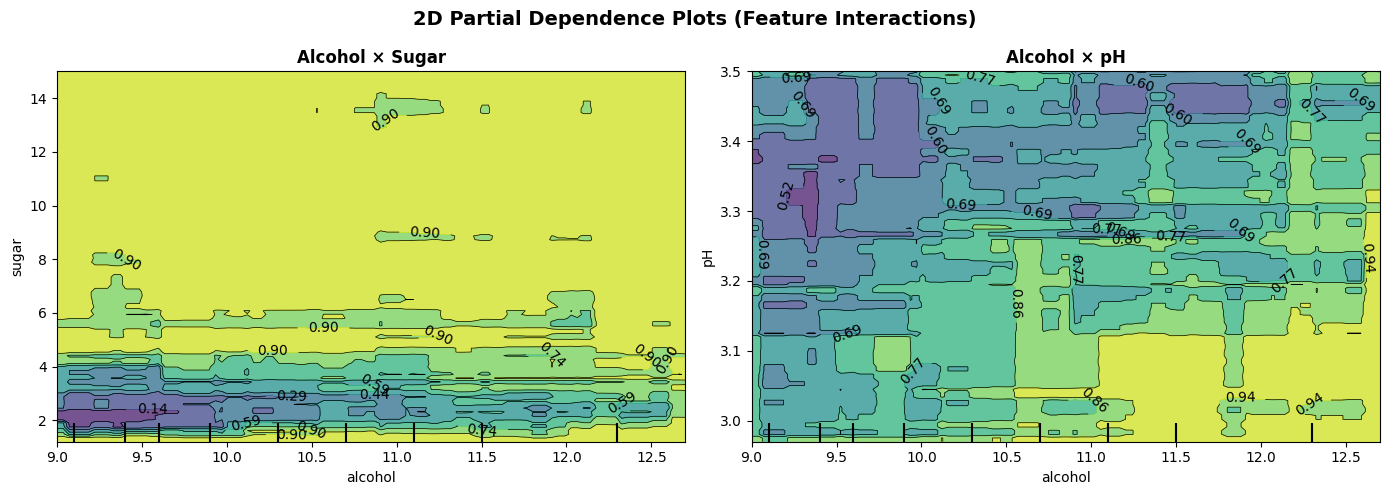


How to read the 2D PDP:
• Colour scale: light = low P(White Wine), dark = high P(White Wine)
• Alcohol × Sugar: The top-right corner (high alcohol + high sugar) is the whitest → clearly White Wine.
  Bottom-left (low alcohol + low sugar) → likely Red Wine.
• Alcohol × pH: Lower pH and higher alcohol → White Wine.
  The two features interact — their combination gives stronger signal than either alone.



In [52]:
# ── 2D PDP: alcohol vs sugar ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('2D Partial Dependence Plots (Feature Interactions)', fontsize=14, fontweight='bold')

# Interaction 1: alcohol × sugar
PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train,
    features=[(0, 1)],              # alcohol (index 0) vs sugar (index 1)
    feature_names=FEATURE_COLS,
    ax=axes[0]
)
axes[0].set_title('Alcohol × Sugar', fontsize=12, fontweight='bold')

# Interaction 2: alcohol × pH
PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train,
    features=[(0, 2)],              # alcohol (index 0) vs pH (index 2)
    feature_names=FEATURE_COLS,
    ax=axes[1]
)
axes[1].set_title('Alcohol × pH', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
How to read the 2D PDP:
• Colour scale: light = low P(White Wine), dark = high P(White Wine)
• Alcohol × Sugar: The top-right corner (high alcohol + high sugar) is the whitest → clearly White Wine.
  Bottom-left (low alcohol + low sugar) → likely Red Wine.
• Alcohol × pH: Lower pH and higher alcohol → White Wine.
  The two features interact — their combination gives stronger signal than either alone.
""")

## Section 9 — Visualise a Single Decision Tree in the Ensemble

XGBoost is made of many trees, and we can visualise **one tree** to inspect the structure.  
Each node in the tree shows:
- The **split condition** (e.g., sugar ≤ 4.35?)
- The **score** the tree assigns if the condition is True/False

Graphviz dot found at: /opt/homebrew/bin/dot


/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


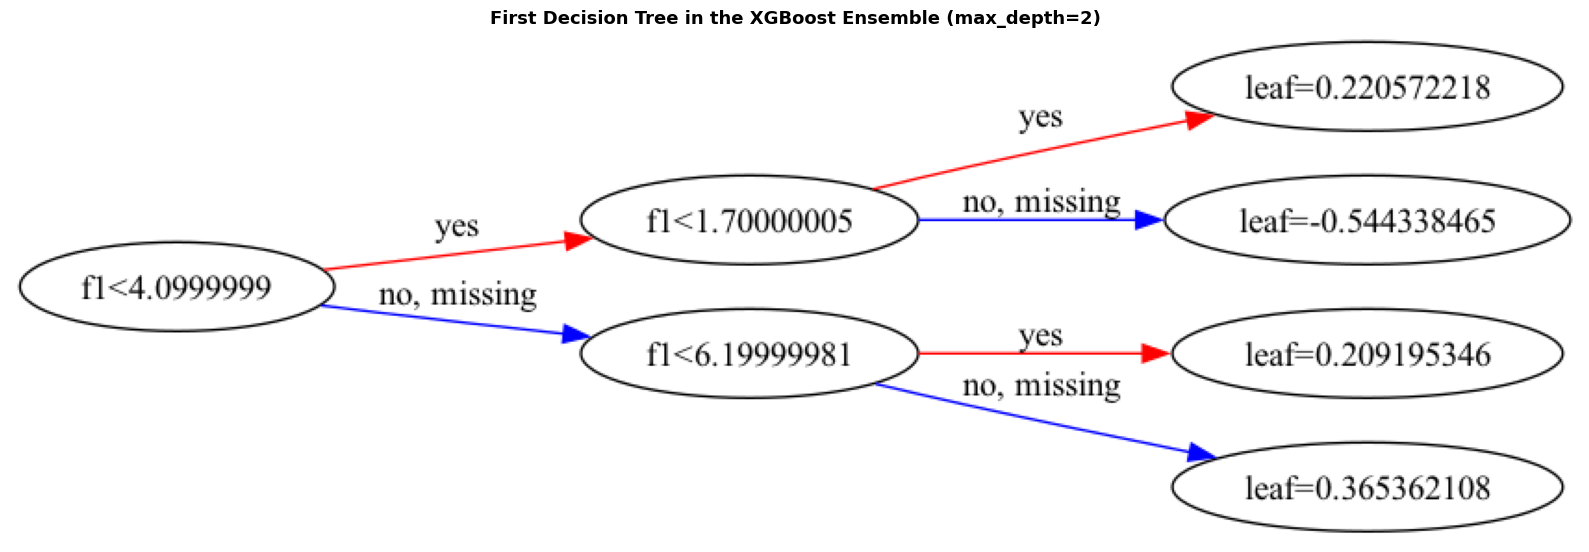


How to read the tree:
• Each box (node) contains a question about a feature value.
• 'f0' = alcohol, 'f1' = sugar, 'f2' = pH
• YES branch (left/down): the condition is TRUE → go left
• NO branch (right/down): the condition is FALSE → go right
• Leaf nodes contain a numerical score (positive = leans White, negative = leans Red)

This is just ONE tree out of 100. The final prediction combines all 100 trees.



In [ ]:
import os
import shutil
from xgboost import plot_tree

# # Ensure Graphviz CLI (dot) is available in the notebook kernel PATH.
# # On Apple Silicon Macs, Homebrew usually installs dot to /opt/homebrew/bin.
# for bin_dir in ['/opt/homebrew/bin', '/usr/local/bin']:
#     if os.path.isdir(bin_dir) and bin_dir not in os.environ.get('PATH', ''):
#         os.environ['PATH'] = f"{bin_dir}:{os.environ['PATH']}"

# dot_path = shutil.which('dot')
# if dot_path is None:
#     raise RuntimeError(
#         "Graphviz executable 'dot' was not found on PATH. "
#         "Install Graphviz with `brew install graphviz` and restart the kernel."
#     )

# print(f"Graphviz dot found at: {dot_path}")

# ── Train a simpler model (shallow trees) for visualisation ────
# max_depth=2: each tree can only ask 2 questions deep — easy to read!
simple_model = XGBClassifier(
    n_estimators=5,          # only 5 trees (not 100) for simplicity
    max_depth=2,             # very shallow trees so we can see the full structure
    learning_rate=0.3,
    eval_metric='logloss',
    random_state=42
)
simple_model.fit(X_train, y_train)

# ── Plot the FIRST tree in the ensemble ────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    simple_model,
    num_trees=0,             # index of the tree to plot (0 = first tree)
    ax=ax,
    rankdir='LR'             # draw left-to-right (easier to read)
)
ax.set_title('First Decision Tree in the XGBoost Ensemble (max_depth=2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
How to read the tree:
• Each box (node) contains a question about a feature value.
• 'f0' = alcohol, 'f1' = sugar, 'f2' = pH
• YES branch (left/down): the condition is TRUE → go left
• NO branch (right/down): the condition is FALSE → go right
• Leaf nodes contain a numerical score (positive = leans White, negative = leans Red)

This is just ONE tree out of 100. The final prediction combines all 100 trees.
""")

## Section 10 — XAI: Explaining a Single Prediction

Given a specific wine sample, how does the model decide?  
We show the predicted probability and how each feature contributes.

This is the "local" level of XAI — explaining **one decision** at a time.

In [54]:
# ── Define a custom wine sample ────────────────────────────────
# You can change these values and see how the prediction changes!
custom_wine = {
    'alcohol': 12.5,   # Alcohol content (%)
    'sugar':   8.0,    # Residual sugar (g/L) — fairly sweet
    'pH':      3.1,    # Fairly acidic
}
sample = np.array([list(custom_wine.values())])

# ── Get probability prediction ─────────────────────────────────
# predict_proba() returns [P(Red), P(White)] for each sample
proba = model.predict_proba(sample)[0]
label = model.predict(sample)[0]

print("=" * 50)
print("Custom wine sample:")
for k, v in custom_wine.items():
    print(f"  {k:10s}: {v}")
print("-" * 50)
print(f"  P(Red Wine)  : {proba[0]:.2%}")
print(f"  P(White Wine): {proba[1]:.2%}")
print(f"  Prediction   : {'White Wine 🤍' if label == 1 else 'Red Wine 🍷'}")
print("=" * 50)
print()
print("Tip: Try changing 'sugar' to 1.0 (dry red wine style) and see what happens!")

Custom wine sample:
  alcohol   : 12.5
  sugar     : 8.0
  pH        : 3.1
--------------------------------------------------
  P(Red Wine)  : 0.47%
  P(White Wine): 99.53%
  Prediction   : White Wine 🤍

Tip: Try changing 'sugar' to 1.0 (dry red wine style) and see what happens!


## Section 11 — Hyperparameter Tuning with GridSearchCV

**Hyperparameters** are settings we choose before training — the model cannot learn them automatically.  
Examples for XGBoost:
- `max_depth`: How deep can each decision tree grow?
- `learning_rate`: How much does each new tree correct the previous error?
- `n_estimators`: How many trees to build?

**GridSearchCV** tries all combinations of hyperparameters and picks the best one using cross-validation.

In [55]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')  # Suppress verbose sklearn warnings

# ── Define the parameter grid ─────────────────────────────────
# We try all combinations of these values → 3 × 2 × 3 = 18 combinations
# With 5-fold cross-validation, that's 18 × 5 = 90 models trained
param_grid = {
    'max_depth':     [3, 5, 7],         # Shallow, medium, deep trees
    'learning_rate': [0.05, 0.1],       # Conservative vs moderate learning speed
    'n_estimators':  [50, 100, 200],    # Number of boosting rounds
}

# ── Run GridSearchCV ───────────────────────────────────────────
# cv=5: 5-fold cross-validation (split training set into 5 parts)
# scoring='accuracy': optimise for overall accuracy
# n_jobs=-1: use all CPU cores to speed up computation
print("Running GridSearchCV (this may take ~30 seconds)...")
gs = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

# ── Show results ───────────────────────────────────────────────
print(f"\n✓ GridSearchCV complete!")
print(f"Best hyperparameters: {gs.best_params_}")
print(f"Best cross-validation accuracy: {gs.best_score_:.4f}")

# Test the best model on the held-out test set
best_model = gs.best_estimator_
tuned_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test accuracy (best model): {tuned_acc:.2%}")
print(f"Test accuracy (default):    {test_acc:.2%}")
print(f"Improvement: {(tuned_acc - test_acc)*100:+.2f} percentage points")

Running GridSearchCV (this may take ~30 seconds)...

✓ GridSearchCV complete!
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best cross-validation accuracy: 0.8797
Test accuracy (best model): 88.31%
Test accuracy (default):    87.77%
Improvement: +0.54 percentage points



CV Accuracy for learning_rate=0.1:
param_n_estimators     50      100     200
param_max_depth                           
3                   0.8695  0.8699  0.8701
5                   0.8693  0.8732  0.8767
7                   0.8740  0.8751  0.8797


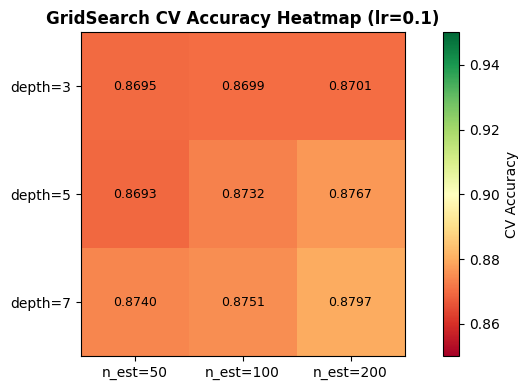

In [56]:
# ── Visualise all hyperparameter combinations ──────────────────
import pandas as pd

# Convert cross-validation results to a DataFrame
results_df = pd.DataFrame(gs.cv_results_)

# Create a pivot table: rows = max_depth, columns = n_estimators, values = mean_test_score
pivot = results_df[
    results_df['param_learning_rate'] == gs.best_params_['learning_rate']
].pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

print(f"\nCV Accuracy for learning_rate={gs.best_params_['learning_rate']}:")
print(pivot.round(4))

# Heat map of the scores
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.85, vmax=0.95)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'n_est={c}' for c in pivot.columns], fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'depth={r}' for r in pivot.index], fontsize=10)
ax.set_title(f'GridSearch CV Accuracy Heatmap (lr={gs.best_params_["learning_rate"]})',
             fontsize=12, fontweight='bold')
plt.colorbar(im, label='CV Accuracy')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.4f}", ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Section 12 — Feature Importance of the Best Model

After tuning, we check if the feature importance has changed.  
The best model might rely on features differently compared to the default model.

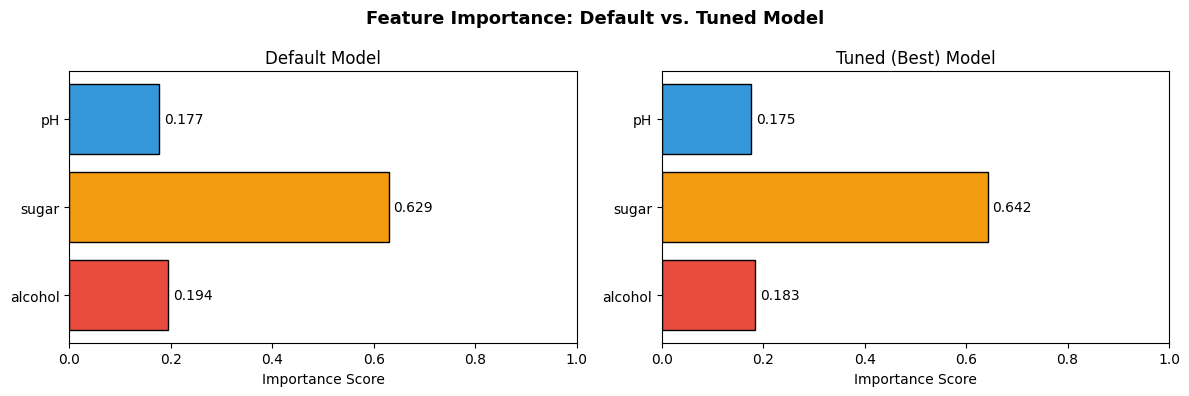

Observation: Feature importance rankings are often stable across hyperparameter settings.
Sugar consistently ranks as the most informative feature.


In [57]:
# ── Compare feature importances: default vs. tuned model ───────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Feature Importance: Default vs. Tuned Model', fontsize=13, fontweight='bold')

for ax, (m, title) in zip(axes, [(model, 'Default Model'), (best_model, 'Tuned (Best) Model')]):
    imp = m.feature_importances_
    ax.barh(FEATURE_COLS, imp, color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='black')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Importance Score')
    ax.set_title(title, fontsize=12)
    for i, v in enumerate(imp):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Observation: Feature importance rankings are often stable across hyperparameter settings.")
print("Sugar consistently ranks as the most informative feature.")

## Section 13 — Summary & Comparison with Ensemble Methods

In the previous `[0410]` lab, we saw these ensemble models on the same wine data:

| Model | Train Score | Test Score | Notes |
|-------|------------|------------|-------|
| Random Forest | ~0.997 | ~0.890 | Independent parallel trees |
| Extra Trees | ~0.997 | ~0.889 | Random split points |
| Gradient Boosting (sklearn) | ~0.888 | ~0.872 | Sequential, slower |
| HistGradientBoosting | ~0.932 | ~0.880 | Histogram binning, fast |
| **XGBoost (this notebook)** | _see above_ | _see above_ | **Extreme Gradient Boosting** |

### XAI Techniques Summary

| Technique | What it shows | Level |
|-----------|--------------|-------|
| Confusion Matrix | Where the model is wrong | Beginner |
| Feature Importance | Which features matter most | Beginner |
| 1D PDP | Effect of one feature | Intermediate |
| 2D PDP | Interaction between two features | Intermediate |
| Decision Tree Visualisation | What one tree "thinks" | Intermediate |
| SHAP (not covered) | Exact contribution of each feature per sample | Advanced |

In [58]:
# ── Final summary dashboard ────────────────────────────────────
print("=" * 55)
print("  XAI Wine Classification — Final Results")
print("=" * 55)
print(f"  Dataset          : Wine (6,497 samples, 3 features)")
print(f"  Target           : Red (0) vs White (1)")
print(f"  Algorithm        : XGBoost")
print("-" * 55)
print(f"  Default Model    : Test Accuracy = {test_acc:.2%}")
print(f"  Tuned Model      : Test Accuracy = {tuned_acc:.2%}")
print("-" * 55)
print(f"  Most Important Feature : sugar")
print(f"  XAI Techniques Applied : Feature Importance, PDP 1D/2D,")
print(f"                           Confusion Matrix, Decision Tree Viz")
print("=" * 55)

  XAI Wine Classification — Final Results
  Dataset          : Wine (6,497 samples, 3 features)
  Target           : Red (0) vs White (1)
  Algorithm        : XGBoost
-------------------------------------------------------
  Default Model    : Test Accuracy = 87.77%
  Tuned Model      : Test Accuracy = 88.31%
-------------------------------------------------------
  Most Important Feature : sugar
  XAI Techniques Applied : Feature Importance, PDP 1D/2D,
                           Confusion Matrix, Decision Tree Viz
